# 03 Exploratory Data Analysis

Objective: visualise pricing, location, room type, availability and review patterns.

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PROCESSED / "cleaned_airbnb_athens.csv")

df.head()

,id,name,host_id,host_since,host_is_superhost,host_response_rate,host_acceptance_rate,host_identity_verified,neighbourhood_cleansed,latitude,...,review_scores_location,review_scores_value,reviews_per_month,has_reviews,instant_bookable,is_entire_home,host_experience_days,estimated_occupancy_l365d,estimated_revenue_l365d,high_price_listing
0,33945,Spacious Cosy aprtm very close to Metro!,146553,2010-06-17,0.0,100.0,84.0,1.0,ΑΓΙΟΣ ΝΙΚΟΛΑΟΣ,38.00673,...,4.64,4.81,0.49,1,0,1,5855.0,128,5760.0,0
1,49489,Ermou 44 - 3bdr apt in the heart of Athens,225612,2010-09-06,0.0,100.0,100.0,1.0,ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,37.97670,...,4.89,4.69,0.83,1,1,1,5774.0,12,1920.0,1
2,60394,Cosy apartment! Great central Athens location!,290864,2010-11-18,1.0,NaN,100.0,1.0,ΣΤΑΔΙΟ,37.96738,...,4.92,4.92,0.29,1,0,1,5701.0,60,3000.0,0
3,154243,LUSCIOUS ROOF GARDEN IN THE CENTER!,741851,2011-06-25,0.0,60.0,77.0,1.0,ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,37.98574,...,4.60,4.66,1.30,1,0,1,5482.0,84,5880.0,0
4,155654,"Acropolis Cosy Apartment, Koukaki",712602,2011-06-17,0.0,100.0,NaN,1.0,ΑΚΡΟΠΟΛΗ,37.96828,...,4.95,4.71,0.47,1,0,1,5490.0,0,0.0,0


In [98]:
df.shape

(14091, 45)

## 1. Price distribution

In [99]:
df["price"].describe()

count    14091.000000
mean        94.618196
std         61.731444
min          9.000000
25%         54.000000
50%         76.000000
75%        114.000000
max        398.000000
Name: price, dtype: float64

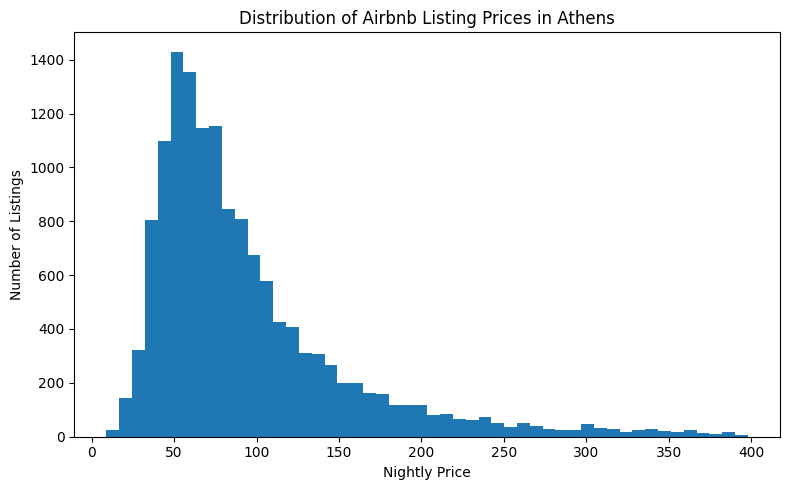

In [100]:
plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=50)
plt.title("Distribution of Airbnb Listing Prices in Athens")
plt.xlabel("Nightly Price")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "price_distribution.png", dpi=300)
plt.show()

## Price Distribution

After cleaning and removing extreme outliers, the price distribution remains right-skewed, which is expected in short-term rental markets. Most listings are concentrated in the lower and middle price ranges, while a smaller number of premium listings remain at the upper end of the distribution.

This supports the decision to use a log-transformed price variable for regression modeling.

## 2. Log price distribution

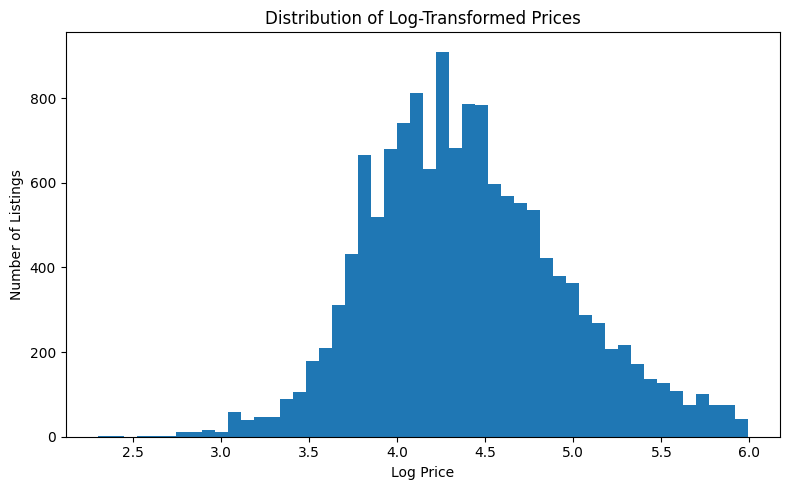

In [101]:
plt.figure(figsize=(8, 5))
plt.hist(df["log_price"], bins=50)
plt.title("Distribution of Log-Transformed Prices")
plt.xlabel("Log Price")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "log_price_distribution.png", dpi=300)
plt.show()

The log-transformed price distribution is more symmetric than the original price variable. This transformation reduces the influence of high-price listings and is more suitable for regression modeling.

## Price Distribution After Cleaning

After cleaning, the dataset contains Airbnb listings with nightly prices ranging from €9 to €398. The median price is €76, while the mean price is €94.62, indicating that the distribution remains right-skewed even after removing extreme outliers.

Most listings are concentrated between €54 and €114, based on the interquartile range. This suggests that the Athens Airbnb market is primarily composed of relatively affordable and mid-priced listings, with fewer premium listings at the upper end of the cleaned distribution.

The remaining skewness supports the use of a log-transformed price variable during the machine learning stage.

## 3. Room type analysis

In [102]:
room_type_summary = (
    df.groupby("room_type")
    .agg(
        number_of_listings=("id", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        average_availability=("availability_365", "mean")
    )
    .sort_values("number_of_listings", ascending=False)
)

room_type_summary

,number_of_listings,median_price,mean_price,average_availability
room_type,,,,
Entire home/apt,13103,77.0,94.940319,259.636877
Private room,906,55.5,89.792494,254.075055
Hotel room,42,140.0,156.000000,263.142857
Shared room,40,25.0,33.950000,321.850000


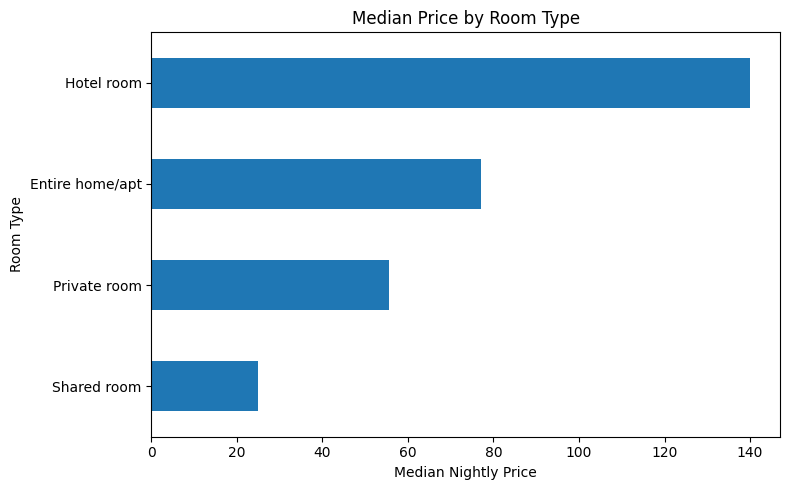

In [103]:
plt.figure(figsize=(8, 5))
room_type_summary["median_price"].sort_values().plot(kind="barh")
plt.title("Median Price by Room Type")
plt.xlabel("Median Nightly Price")
plt.ylabel("Room Type")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "median_price_by_room_type.png", dpi=300)
plt.show()

## Room Type and Pricing Patterns

The room type analysis confirms that entire homes or apartments dominate the cleaned dataset, with 13,103 listings. Their median nightly price is €77, which is higher than private rooms but lower than hotel rooms.

Hotel rooms show the highest median price at €140, but this category contains only 42 listings. Therefore, this result should be interpreted carefully because it is based on a small number of observations.

Private rooms have a lower median price of €55.5, while shared rooms are the cheapest category, with a median price of €25. Shared rooms also show the highest average availability, suggesting lower demand or less frequent booking compared with other room types.

Overall, room type appears to be relevant for pricing, but because entire homes/apartments dominate the dataset, price variation is likely to be driven more strongly by neighbourhood, capacity, property characteristics and amenities.

## 4. Neighbourhood price analysis

In [104]:
neighbourhood_summary = (
    df.groupby("neighbourhood_cleansed")
    .agg(
        number_of_listings=("id", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean"),
        high_price_share=("high_price_listing", "mean")
    )
    .sort_values("number_of_listings", ascending=False)
)

neighbourhood_summary.head(15)

,number_of_listings,median_price,mean_price,high_price_share
neighbourhood_cleansed,,,,
ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,2887,107.0,124.322826,0.447523
ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,1308,96.0,116.116208,0.369266
ΝΕΟΣ ΚΟΣΜΟΣ,1088,70.0,86.148897,0.183824
ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,1013,71.0,85.545903,0.166831
ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,886,55.0,65.775395,0.071106
ΠΑΓΚΡΑΤΙ,585,68.0,78.767521,0.141880
ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,522,52.0,60.208812,0.047893
ΚΟΛΩΝΑΚΙ,468,101.5,125.863248,0.440171
ΑΚΡΟΠΟΛΗ,438,104.5,123.484018,0.436073


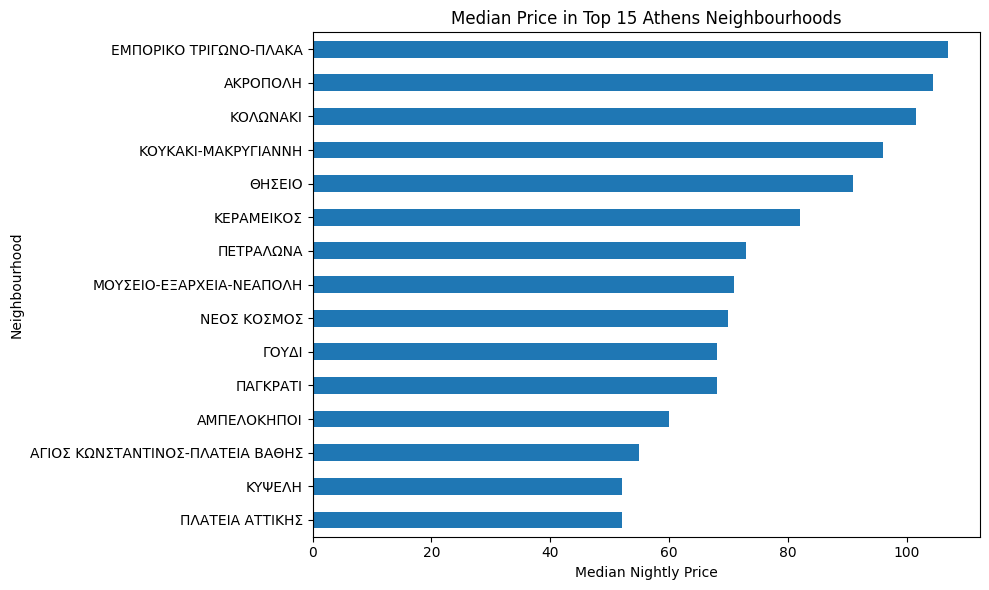

In [105]:
top_neighbourhoods = neighbourhood_summary.head(15)

plt.figure(figsize=(10, 6))
top_neighbourhoods["median_price"].sort_values().plot(kind="barh")
plt.title("Median Price in Top 15 Athens Neighbourhoods")
plt.xlabel("Median Nightly Price")
plt.ylabel("Neighbourhood")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "median_price_top_neighbourhoods.png", dpi=300)
plt.show()

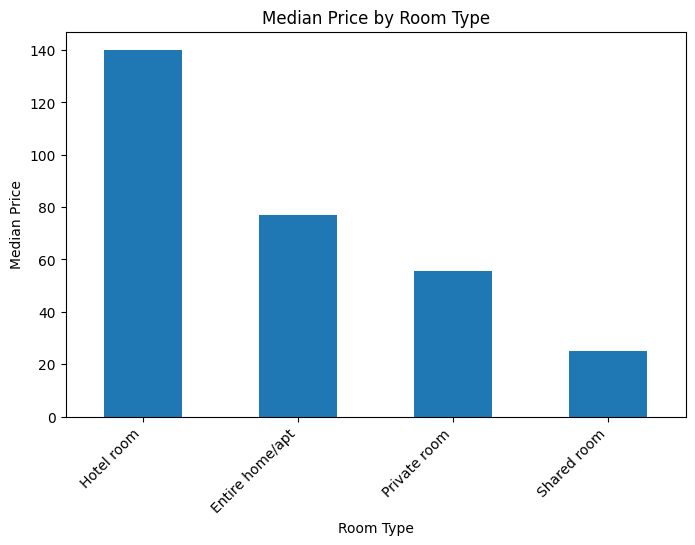

In [106]:
room_price = df.groupby("room_type")["price"].median().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
room_price.plot(kind="bar")
plt.title("Median Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Median Price")
plt.xticks(rotation=45, ha="right")
plt.show()

In [107]:
top_neighbourhoods = (
    df.groupby("neighbourhood_cleansed")
    .agg(listings=("id", "count"), median_price=("price", "median"))
    .sort_values("listings", ascending=False)
    .head(15)
)

top_neighbourhoods

,listings,median_price
neighbourhood_cleansed,,
ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,2887,107.0
ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,1308,96.0
ΝΕΟΣ ΚΟΣΜΟΣ,1088,70.0
ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,1013,71.0
ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,886,55.0
ΠΑΓΚΡΑΤΙ,585,68.0
ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,522,52.0
ΚΟΛΩΝΑΚΙ,468,101.5
ΑΚΡΟΠΟΛΗ,438,104.5


In [108]:
neighbourhood_summary_display = neighbourhood_summary.copy()

neighbourhood_summary_display["mean_price"] = neighbourhood_summary_display["mean_price"].round(2)
neighbourhood_summary_display["median_price"] = neighbourhood_summary_display["median_price"].round(2)
neighbourhood_summary_display["high_price_share"] = (
    neighbourhood_summary_display["high_price_share"] * 100
).map(lambda x: f"{x:.2f}%")

neighbourhood_summary_display.head(15)

,number_of_listings,median_price,mean_price,high_price_share
neighbourhood_cleansed,,,,
ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ,2887,107.0,124.32,44.75%
ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ,1308,96.0,116.12,36.93%
ΝΕΟΣ ΚΟΣΜΟΣ,1088,70.0,86.15,18.38%
ΜΟΥΣΕΙΟ-ΕΞΑΡΧΕΙΑ-ΝΕΑΠΟΛΗ,1013,71.0,85.55,16.68%
ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ,886,55.0,65.78,7.11%
ΠΑΓΚΡΑΤΙ,585,68.0,78.77,14.19%
ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ,522,52.0,60.21,4.79%
ΚΟΛΩΝΑΚΙ,468,101.5,125.86,44.02%
ΑΚΡΟΠΟΛΗ,438,104.5,123.48,43.61%


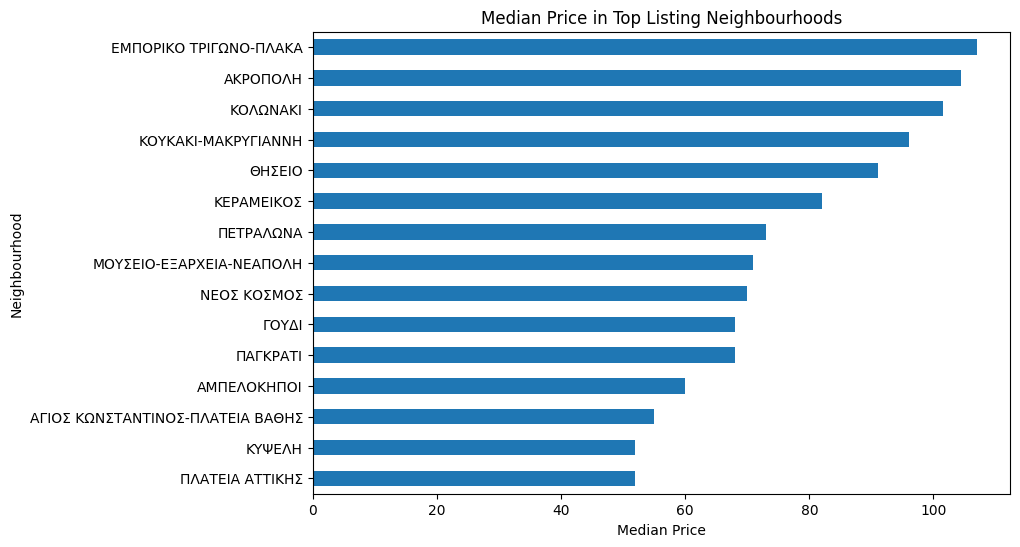

In [109]:
plt.figure(figsize=(9, 6))
top_neighbourhoods["median_price"].sort_values().plot(kind="barh")
plt.title("Median Price in Top Listing Neighbourhoods")
plt.xlabel("Median Price")
plt.ylabel("Neighbourhood")
plt.show()

## Neighbourhood-Level Market Patterns

The neighbourhood analysis shows substantial differences in pricing across Athens. `ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ` has the largest number of listings and also one of the highest median prices, at €107. This suggests that central tourist areas combine both high supply and strong pricing power.

Premium neighbourhoods such as `ΚΟΛΩΝΑΚΙ`, `ΑΚΡΟΠΟΛΗ`, `ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ` and `ΚΟΥΚΑΚΙ-ΜΑΚΡΥΓΙΑΝΝΗ` show high median prices and high shares of high-price listings. For example, `ΚΟΛΩΝΑΚΙ`, `ΑΚΡΟΠΟΛΗ` and `ΕΜΠΟΡΙΚΟ ΤΡΙΓΩΝΟ-ΠΛΑΚΑ` all have high-price listing shares above 43%.

In contrast, neighbourhoods such as `ΠΛΑΤΕΙΑ ΑΤΤΙΚΗΣ`, `ΚΥΨΕΛΗ`, `ΑΜΠΕΛΟΚΗΠΟΙ` and `ΑΓΙΟΣ ΚΩΝΣΤΑΝΤΙΝΟΣ-ΠΛΑΤΕΙΑ ΒΑΘΗΣ` have lower median prices and lower high-price listing shares. This confirms that location is likely to be one of the strongest predictors of Airbnb pricing in Athens.

## 5. Price by accommodates

In [110]:
accommodates_summary = (
    df.groupby("accommodates")
    .agg(
        number_of_listings=("id", "count"),
        median_price=("price", "median"),
        mean_price=("price", "mean")
    )
)

accommodates_summary

,number_of_listings,median_price,mean_price
accommodates,,,
1,199,28.0,37.824121
2,4533,63.0,77.971542
3,1903,67.0,79.865476
4,4443,79.0,95.037362
5,1027,91.0,106.906524
6,1319,109.0,131.080364
7,191,120.0,144.853403
8,252,151.0,171.218254
9,53,199.0,204.018868


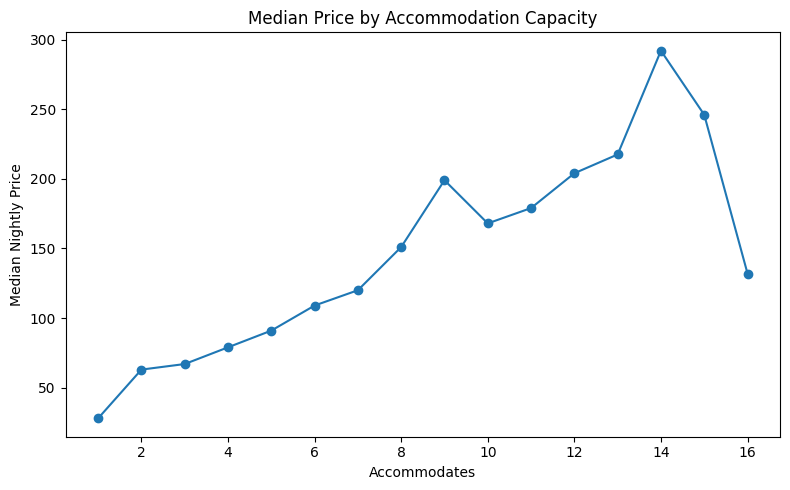

In [111]:
plt.figure(figsize=(8, 5))
accommodates_summary["median_price"].plot(kind="line", marker="o")
plt.title("Median Price by Accommodation Capacity")
plt.xlabel("Accommodates")
plt.ylabel("Median Nightly Price")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "median_price_by_accommodates.png", dpi=300)
plt.show()

## 6. Review scores and price

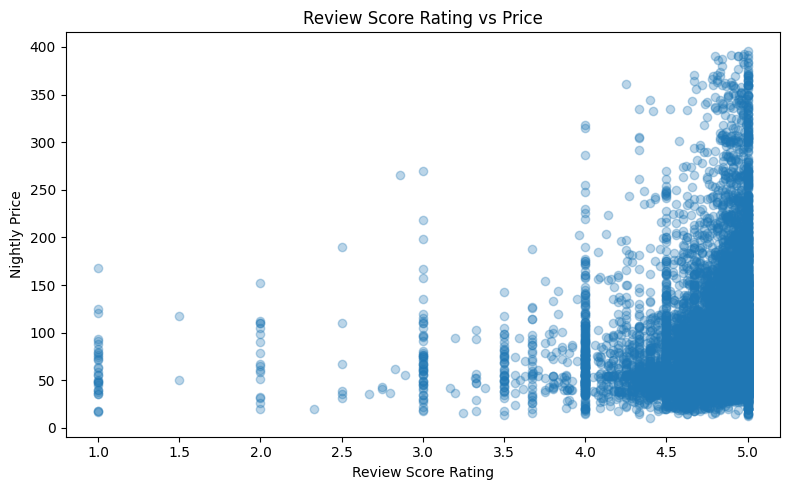

In [112]:
plt.figure(figsize=(8, 5))
plt.scatter(df["review_scores_rating"], df["price"], alpha=0.3)
plt.title("Review Score Rating vs Price")
plt.xlabel("Review Score Rating")
plt.ylabel("Nightly Price")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "review_score_vs_price.png", dpi=300)
plt.show()

The relationship between review score and price is not strictly linear. Very high ratings are common across many listings, so review scores may help explain quality differences but are unlikely to be the only driver of price.

## 7. Correlation table for numeric variables

In [113]:
numeric_cols = [
    "price",
    "log_price",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "amenities_count",
    "minimum_nights",
    "availability_365",
    "availability_rate",
    "number_of_reviews",
    "review_scores_rating",
    "reviews_per_month",
    "host_experience_days",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d"
]

available_numeric_cols = [col for col in numeric_cols if col in df.columns]

correlation_with_price = (
    df[available_numeric_cols]
    .corr(numeric_only=True)["price"]
    .sort_values(ascending=False)
)

correlation_with_price

price                        1.000000
log_price                    0.933998
accommodates                 0.385195
bathrooms                    0.363145
bedrooms                     0.350925
estimated_revenue_l365d      0.330938
beds                         0.294241
review_scores_rating         0.136755
amenities_count              0.121472
availability_365             0.071757
availability_rate            0.071757
host_experience_days         0.033322
reviews_per_month           -0.035690
number_of_reviews           -0.038565
minimum_nights              -0.044975
estimated_occupancy_l365d   -0.088075
Name: price, dtype: float64

## Correlation with Price

The correlation analysis shows that the strongest numeric predictors of price are related to property capacity and size. `accommodates`, `bathrooms`, `bedrooms` and `beds` all have positive correlations with price, indicating that larger listings tend to command higher nightly prices.

The strongest positive correlation is observed for `accommodates` at approximately 0.39, followed by `bathrooms` and `bedrooms`. This suggests that the number of guests a property can host is one of the most important quantitative drivers of price.

Review-related variables show weaker relationships with price. `review_scores_rating` has a small positive correlation, while `number_of_reviews` and `reviews_per_month` are slightly negative. This suggests that review volume is not necessarily associated with higher prices and may instead reflect more frequently booked or more affordable listings.

Availability has only a weak positive relationship with price. Estimated occupancy is negatively correlated with price, which may indicate that lower-priced listings are booked more frequently.

Overall, the correlation analysis suggests that price prediction should include property capacity variables, neighbourhood, room type, property type, amenities and review indicators.

## 8. Save EDA summary tables

In [114]:
room_type_summary.to_csv(FIGURES_DIR / "room_type_summary.csv")
neighbourhood_summary.to_csv(FIGURES_DIR / "neighbourhood_summary.csv")
correlation_with_price.to_csv(FIGURES_DIR / "correlation_with_price.csv")

print("EDA summary files saved successfully.")

EDA summary files saved successfully.


## Notebook 03 Summary

The exploratory analysis shows that the Athens Airbnb market is dominated by entire homes and apartments, with strong concentration in central neighbourhoods. Prices vary substantially by location and room type, while property capacity variables such as accommodates, bedrooms and bathrooms show the strongest numeric relationships with price.

The findings support the next stage of the project: building machine learning models that combine property characteristics, location, room type, host information, reviews and availability variables to predict listing prices and classify high-price listings.